## 1. Setup and Imports

In [6]:
from sage.all import *
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/bitcoin_timeseries.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')


## 2. Select and Normalize Subset for Modeling (14 Days)

In [7]:
# Get last timestamp and build mask manually
last_timestamp = df.index.max()
recent = df.loc[df.index >= last_timestamp - pd.Timedelta(days=14)]

# Resample to hourly, drop missing, reset index
df_model = recent.resample('1h').mean().dropna().reset_index()

# Use only last 100 data points for stability
df_model = df_model.tail(100)

# Normalize time: convert to hours, then center around mean
timestamps = df_model['timestamp']
x_vals = [(t - timestamps.iloc[0]).total_seconds() / int(3600) for t in timestamps]
x_mean = sum(x_vals) / len(x_vals)
x_vals = [x - x_mean for x in x_vals]

# Get y-values
y_vals = list(df_model['price_usd'])

print(f"✅ Using {len(x_vals)} normalized points from last 14 days")


✅ Using 100 normalized points from last 14 days


## 3. Symbolic Least Squares Polynomial Fit (Degree 3)

In [8]:
# Declare variable and parameters
x = var('x')
a0, a1, a2, a3 = var('a0 a1 a2 a3')
params = [a0, a1, a2, a3]

# Model
model = a0 + a1*x + a2*x**2 + a3*x**3

# Prepare data: (x, y) tuples
points = list(zip(x_vals, y_vals))

# Fit the model
fit = find_fit(points, model, parameters=params, variables=[x], solution_dict=True)

# Substitute fitted values into model
model_fitted = model.subs(fit)
model_fitted


0.00866564610758422*x^3 - 0.08849322968581545*x^2 - 9.38490426617415*x + 103468.84084706436

## 4. Plot Fitted Polynomial vs Actual

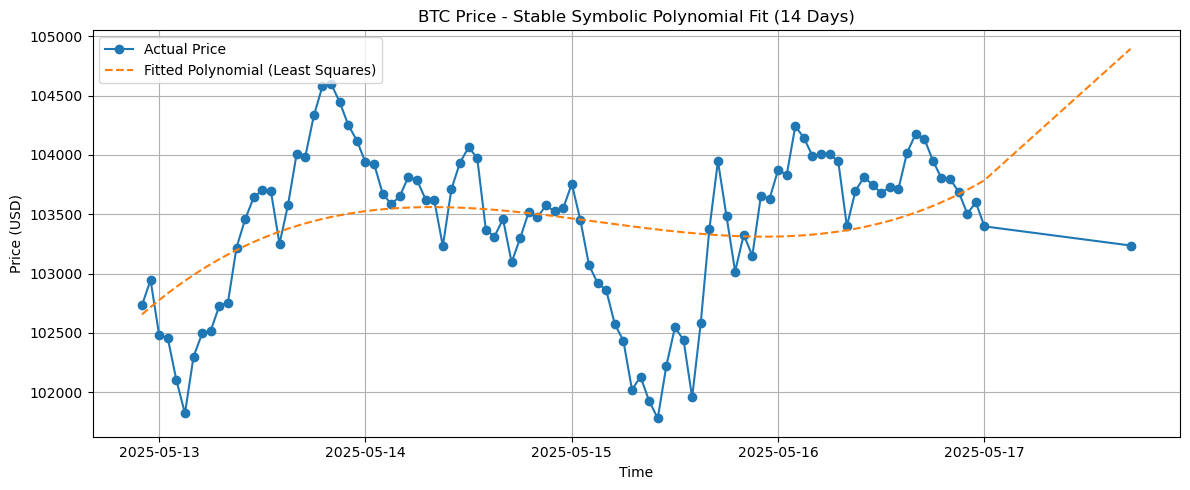

In [9]:
f = lambda t: float(model_fitted.subs(x=t))
y_fit = [f(t) for t in x_vals]

plt.figure(figsize=(12, 5))
plt.plot(df_model['timestamp'], y_vals, label='Actual Price', marker='o')
plt.plot(df_model['timestamp'], y_fit, label='Fitted Polynomial (Least Squares)', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.title("BTC Price - Stable Symbolic Polynomial Fit (14 Days)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../reports/symbolic_polynomial_fit.png')
plt.show()


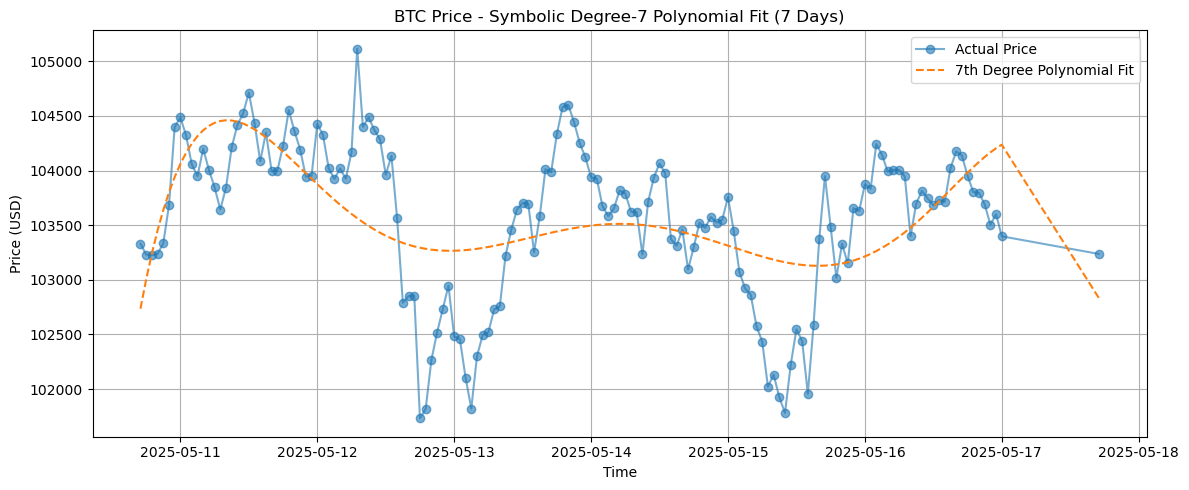

In [10]:
# Use last 7 days, hourly resampled
recent = df.loc[df.index >= df.index.max() - pd.Timedelta(days=7)]
df_model = recent.resample('1h').mean().dropna().reset_index()

# Convert timestamps to normalized hours
timestamps = df_model['timestamp']
x_vals = [(t - timestamps.iloc[0]).total_seconds() / 3600 for t in timestamps]
x_mean = sum(x_vals) / len(x_vals)
x_vals = [x - x_mean for x in x_vals]
y_vals = list(df_model['price_usd'])

# Declare variable and parameters for degree-7 model
x = var('x')
params = list(var('a0 a1 a2 a3 a4 a5 a6 a7'))
model = sum(params[i] * x**i for i in range(8))  # degree 7 = 8 terms

# Perform symbolic least squares fit
points = list(zip(x_vals, y_vals))
fit = find_fit(points, model, parameters=params, variables=[x], solution_dict=True)

# Substitute fitted values into model
model_fitted = model.subs(fit)

# Evaluate model
f = lambda t: float(model_fitted.subs(x=t))
y_fit = [f(t) for t in x_vals]

# Plot
plt.figure(figsize=(12, 5))
plt.plot(df_model['timestamp'], y_vals, label='Actual Price', marker='o', alpha=0.6)
plt.plot(df_model['timestamp'], y_fit, label='7th Degree Polynomial Fit', linestyle='--')
plt.title("BTC Price - Symbolic Degree-7 Polynomial Fit (7 Days)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/symbolic_polynomial_fit_deg7_7D.png')
plt.show()
